In [ ]:
# --- Setup (roda sozinho; necessário só no Google Colab) ---
import os, sys
if "google.colab" in sys.modules and not os.path.exists("LAB"):
    !git clone -q https://github.com/pemodest0/Low-energy-scattering.git LAB
if os.path.exists("LAB"):
    sys.path.insert(0, "LAB")
else:
    sys.path.insert(0, os.path.abspath(".."))   # rodando localmente
print("setup ok")

# As fórmulas na prática — rode, mexa e veja o que sai

**Para: Pedro (considere-me leigo).** Cada seção segue o mesmo ritual:

1. 📐 **A fórmula** (renderizada bonitinha)
2. 🗣️ **Tradução símbolo por símbolo** (o que cada letra É)
3. 💻 **Código** que usa a fórmula de verdade
4. 📊 **Gráfico** com cada eixo e cada curva explicados
5. 🔧 **MEXA AQUI**: o que acontece se você mudar cada número

Rode as células em ordem com `Shift+Enter`. Nada aqui quebra nada:
pode mudar os números à vontade e rodar de novo.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from src import espalhamento, analitico
from src.potenciais import PocoEsferico, PoschlTeller, Gaussiano, LennardJones
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11})
print('pronto! pacote carregado.')

pronto! pacote carregado.


---
## 1. A equação que resolvemos o tempo todo

$$\boxed{\;u''(r) = 2\,\bar V(r)\,u(r)\;}$$

🗣️ **Tradução:**

| símbolo | o que é |
|---|---|
| $r$ | distância entre os DOIS átomos/núcleons (não é posição de um só!). Unidade: fm ($10^{-15}$ m) |
| $u(r)$ | a "função de onda reduzida": $u = r\cdot\psi(r)$. É só um truque que transforma o problema 3D numa equação 1D |
| $u''(r)$ | a segunda derivada — a *curvatura* do gráfico de $u$ |
| $\bar V(r)$ | o potencial de interação, já em unidades adimensionais ($\hbar = m_r = 1$) |
| $2$ | vem do $2m_r/\hbar^2$ da equação de Schrödinger quando $\hbar=m_r=1$ |

🧠 **A intuição inteira está nesta leitura:** a equação diz
*"curvatura de $u$ = potencial × valor de $u$"*.

- Onde $\bar V < 0$ (atrativo) e $u>0$: curvatura **negativa** → a curva
  entorta **para baixo** (como se algo puxasse).
- Onde $\bar V = 0$ (fora do alcance): curvatura **zero** → $u$ vira uma
  **RETA**. Essa reta é $g_0(r) = 1 - r/a$, e o $a$ dela é o comprimento
  de espalhamento.

Vamos VER isso:

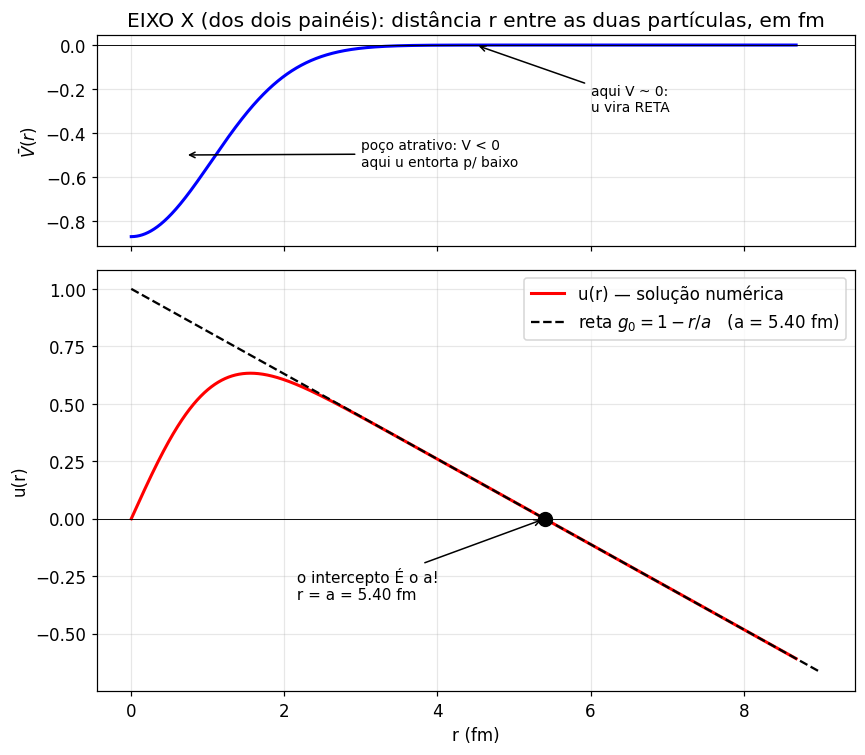

a  = 5.4003 fm | r0 = 1.6989 fm | nós = 1


In [2]:
# 🔧 MEXA AQUI: troque v (profundidade) e mu (1/alcance) e rode de novo
v, mu = 1.9102, 0.6754        # valores do "dêuteron gaussiano" (Tabela 3)

pot = Gaussiano(v, mu)
res = espalhamento.calcular(pot, dr=1e-3)
r, u = res.r, res.u

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 2]})
m = r <= 9
# --- painel de cima: o potencial ---
ax1.plot(r[m], pot.V(r[m]), 'b-', lw=2)
ax1.axhline(0, color='k', lw=0.6)
ax1.set_ylabel('$\\bar V(r)$')
ax1.set_title('EIXO X (dos dois painéis): distância r entre as duas partículas, em fm')
ax1.annotate('poço atrativo: V < 0\naqui u entorta p/ baixo', xy=(0.7, -0.5),
             xytext=(3, -0.55), arrowprops=dict(arrowstyle='->'), fontsize=9)
ax1.annotate('aqui V ~ 0:\nu vira RETA', xy=(4.5, 0), xytext=(6, -0.3),
             arrowprops=dict(arrowstyle='->'), fontsize=9)
# --- painel de baixo: a solução ---
ax2.plot(r[m], u[m], 'r-', lw=2, label='u(r) — solução numérica')
rr = np.linspace(0, 9, 300)
ax2.plot(rr, 1 - rr/res.a, 'k--', lw=1.5, label=f'reta $g_0 = 1 - r/a$   (a = {res.a:.2f} fm)')
ax2.plot([res.a], [0], 'ko', ms=9)
ax2.annotate(f' o intercepto É o a!\n r = a = {res.a:.2f} fm', (res.a, 0),
             xytext=(res.a-3.3, -0.35), fontsize=10,
             arrowprops=dict(arrowstyle='->'))
ax2.axhline(0, color='k', lw=0.6)
ax2.set_xlabel('r (fm)'); ax2.set_ylabel('u(r)')
ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

print(f'a  = {res.a:.4f} fm | r0 = {res.r0:.4f} fm | nós = {res.nos}')

📊 **Como ler o gráfico acima:**

- **Eixo x (os dois painéis):** a distância $r$ entre as duas partículas, em fm.
- **Painel de cima, curva azul:** o potencial $\bar V(r)$ — o "vale" perto de
  $r=0$ é a atração; ele morre rápido (aqui, uma gaussiana).
- **Painel de baixo, curva vermelha:** a solução $u(r)$. Dentro do vale ela
  entorta; passado o vale, vira exatamente a **reta preta tracejada**.
- **A bolinha preta:** onde a reta cruza zero → esse ponto é $r = a$.
  Todo o efeito do potencial ficou comprimido nesse único número.

🔧 **MEXA AQUI (experimentos sugeridos):**

- `v = 0.9` → o poço fica raso demais pra ligar: a reta vai cruzar zero em
  $r$ **negativo** (você não vê o intercepto no gráfico; $a<0$). Sem estado ligado.
- `v = 1.3420` → o limiar exato: a reta fica **horizontal** ($a = \infty$).
- `v = 3.0` → poço fundo: $a$ fica pequeno e positivo, e aparece mais um nó em $u$.
- `mu = 1.2` → potencial mais curto (alcance $\sim 1/\mu$): tudo acontece mais perto da origem.

---
## 2. Como o computador extrai o $a$ — Eq. (110) do artigo

O computador não "vê" a reta. Ele usa a derivada logarítmica de $u$ no fim
do alcance $R$:

$$\boxed{\;a \;=\; R \;-\; \frac{2\,\Delta r\;u(R)}{u(R+\Delta r)-u(R-\Delta r)}\;}$$

🗣️ **Tradução:** se $u$ já é a reta $1-r/a$ em $r=R$, então a inclinação
da reta é $[u(R+\Delta r)-u(R-\Delta r)]/(2\Delta r)$ (diferença central)
e o valor é $u(R)$. Dividir valor por inclinação e ajeitar dá exatamente
onde a reta cruza zero. **É geometria de reta, nada mais.**

| símbolo | o que é |
|---|---|
| $R$ | onde o potencial "acabou" (definimos: onde $|\bar V| \le 10^{-15}$) |
| $\Delta r$ | o passo da grade numérica (ex.: 0,001 fm) |
| $u(R\pm\Delta r)$ | a solução nos pontos vizinhos de $R$ |

Vamos conferir que isso dá o mesmo que "esticar a reta no olho":

In [3]:
pot = PoschlTeller(0.9071, 0.7991)      # caso nêutron-nêutron (a < 0)
res = espalhamento.calcular(pot, dr=1e-3)

# reconstruindo a Eq. (110) "na mão" para conferir:
r, u, dr = res.r, res.u, res.dr
N = round((res.R_match - r[0]) / dr)     # índice do ponto r = R
a_manual = res.R_match - 2*dr*u[N] / (u[N+1] - u[N-1])

print(f'a pela Eq. (110) refeita aqui : {a_manual:.6f} fm')
print(f'a que o pacote devolve        : {res.a:.6f} fm')
print(f'a analítico exato (Eq. 117)   : {analitico.a_mpt(0.9071, 0.7991):.6f} fm')
print()
print('a é NEGATIVO: o potencial quase forma estado ligado, mas não forma.')
print('Módulo grande (18,5 fm >> alcance ~1,3 fm) = "quase ligou".')

a pela Eq. (110) refeita aqui : -18.515134 fm
a que o pacote devolve        : -18.515134 fm
a analítico exato (Eq. 117)   : -18.515134 fm

a é NEGATIVO: o potencial quase forma estado ligado, mas não forma.
Módulo grande (18,5 fm >> alcance ~1,3 fm) = "quase ligou".


---
## 3. O caso com resposta exata: o poço esférico — Eq. (80)

Para o poço quadrado dá pra resolver TUDO no papel:

$$\boxed{\;a = R\left(1 - \frac{\tan\sqrt{2v}}{\sqrt{2v}}\right)\;}$$

🗣️ **Tradução:** $R$ = raio do poço; $v$ = profundidade (adimensional);
$\sqrt{2v} = k_0 R$ é "quantas oscilações a onda dá dentro do poço".
A **tangente** é quem manda: quando $\sqrt{2v} = \pi/2$ (ou seja,
$v = \pi^2/8 \approx 1{,}2337$), $\tan \to \infty$ e o $a$ **explode** —
é o nascimento do primeiro estado ligado.

O gráfico abaixo compara o computador (bolinhas) com a fórmula (linha):

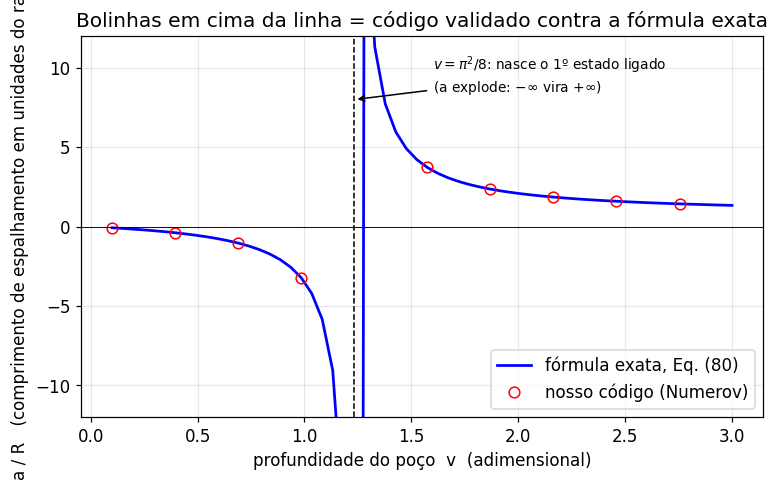

In [4]:
vs = np.linspace(0.1, 3.0, 60)
a_analitico = [analitico.a_poco(v, R=1.0) for v in vs]
vs_num = vs[::6]                                # menos pontos p/ ficar legível
a_numerico = [espalhamento.calcular(PocoEsferico(v, 1.0), dr=5e-4).a
              for v in vs_num]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(vs, a_analitico, 'b-', lw=1.8, label='fórmula exata, Eq. (80)')
ax.plot(vs_num, a_numerico, 'ro', ms=7, mfc='none', label='nosso código (Numerov)')
ax.axvline(np.pi**2/8, color='k', ls='--', lw=1)
ax.annotate('$v = \\pi^2/8$: nasce o 1º estado ligado\n(a explode: $-\\infty$ vira $+\\infty$)',
            (np.pi**2/8, 8), xytext=(1.6, 8.5), fontsize=9,
            arrowprops=dict(arrowstyle='->'))
ax.set_ylim(-12, 12); ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('profundidade do poço  v  (adimensional)')
ax.set_ylabel('a / R   (comprimento de espalhamento em unidades do raio)')
ax.legend(); ax.set_title('Bolinhas em cima da linha = código validado contra a fórmula exata')
plt.show()

📊 **Como ler:**

- **Eixo x:** a profundidade $v$ do poço. Girar esse botão = tornar a atração mais forte.
- **Eixo y:** $a$ em unidades do raio $R$ do poço.
- **Linha azul:** a fórmula exata. **Bolinhas vermelhas:** nosso código —
  caem exatamente em cima (é assim que se valida código científico).
- **A parede tracejada:** em $v = \pi^2/8$ o denominador da física zera.
  À esquerda: $a<0$ e cada vez mais negativo ("quase liga"). À direita:
  $a>0$ vindo de $+\infty$ (estado ligado recém-nascido, gigante e frouxo).

🔧 **MEXA AQUI:** estique `vs` até 8.0 e você verá a curva explodir DE NOVO
perto de $v = 9\pi^2/8 \approx 11{,}1$… não, espere: a segunda explosão é em
$\sqrt{2v} = 3\pi/2$, ou seja $v \approx 11{,}1$. Cada explosão = mais um
estado ligado cabendo no poço.

---
## 4. O alcance efetivo $r_0$ — Eq. (56)

$$\boxed{\;r_0 = 2\int_0^{R}\left[g_0^2(r) - u_0^2(r)\right]\,dr\;}$$

🗣️ **Tradução:** compare a solução verdadeira $u_0$ com a reta idealizada
$g_0 = 1-r/a$ (que é o que um potencial de alcance ZERO produziria).
A **área entre os quadrados das duas** mede "quanto potencial de verdade
existe ali dentro" — um tamanho efetivo da região de interação.
Antes de integrar, normalizamos $u$ para colar na reta em $r=R$:
$C = (1 - R/a)/u(R)$ — Eq. (111).

O integrando é uma coisa que dá pra VER:

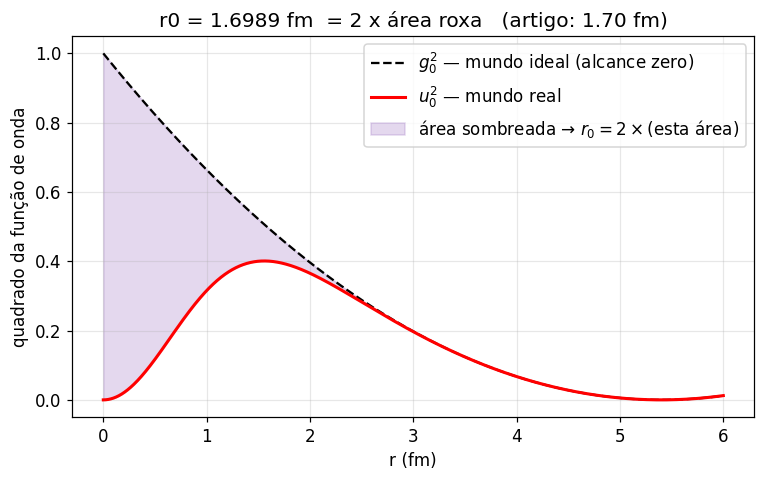

trapézio: 1.698931 fm | Simpson: 1.698931 fm  (duas quadraturas, mesmo valor)


In [5]:
pot = Gaussiano(1.9102, 0.6754)          # dêuteron gaussiano de novo
res = espalhamento.calcular(pot, dr=1e-3)
r, u = res.r, res.u
g0 = 1 - r/res.a
integrando = g0**2 - u**2

fig, ax = plt.subplots(figsize=(8, 4.5))
m = r <= 6
ax.plot(r[m], g0[m]**2, 'k--', lw=1.5, label='$g_0^2$ — mundo ideal (alcance zero)')
ax.plot(r[m], u[m]**2, 'r-', lw=2, label='$u_0^2$ — mundo real')
ax.fill_between(r[m], u[m]**2, g0[m]**2, alpha=0.25, color='tab:purple',
                label='área sombreada → $r_0 = 2\\times$(esta área)')
ax.set_xlabel('r (fm)'); ax.set_ylabel('quadrado da função de onda')
ax.legend()
ax.set_title(f'r0 = {res.r0:.4f} fm  = 2 x área roxa   (artigo: 1.70 fm)')
plt.show()
print(f'trapézio: {res.r0_trap:.6f} fm | Simpson: {res.r0_simp:.6f} fm  (duas quadraturas, mesmo valor)')

📊 **Como ler:**

- **Tracejada preta:** $g_0^2$, o que seria se o potencial tivesse alcance zero.
- **Vermelha:** $u_0^2$ real — difere da tracejada SÓ dentro do alcance.
- **Área roxa:** a diferença. $r_0$ = duas vezes essa área. Por isso
  $r_0 \approx$ "tamanho da região onde o potencial age" (~1,7 fm aqui).

🔧 **MEXA AQUI:** troque para `PocoEsferico(1.7575, 0.5)` — o poço do
dêuteron. O $r_0$ dá o MESMO 1,70 fm com um potencial de forma totalmente
diferente. É a universalidade em ação.

---
## 5. Dois números → energia do dêuteron — Eqs. (93) e (95)

**Alcance zero (grosseira):**
$$E_{zr} = -\frac{\hbar^2}{2 m_r a^2}$$

**Com correção de alcance (fina):** primeiro resolvemos
$$\frac{1}{a} = \kappa - \frac{1}{2} r_0 \kappa^2 \qquad\Rightarrow\qquad E_{fr} = -\frac{\hbar^2 \kappa^2}{2 m_r}$$

🗣️ **Tradução:** $\kappa$ é o "momento de decaimento" do estado ligado
(a função de onda ligada morre como $e^{-\kappa r}$); $m_r$ é a massa
reduzida do par próton-nêutron. A 1ª fórmula usa só $a$; a 2ª corrige
com $r_0$. Veja a diferença que o $r_0$ faz:

In [6]:
from src import constantes as cte
h22m = cte.hbar2_over_2mr_MeV_fm2(cte.M_R_NP_MEV)   # ħ²/(2 m_r) em MeV.fm²
a_exp, r0_exp = 5.4112, 1.7436                      # valores medidos (fm)

E_zr = analitico.energia_zr(a_exp, h22m)
E_fr = analitico.energia_fr(a_exp, r0_exp, h22m)
kappa = (1 - np.sqrt(1 - 2*r0_exp/a_exp)) / r0_exp

print(f'só com a           : E_zr = {E_zr:+.3f} MeV   (erro de 36%!)')
print(f'com a e r0         : E_fr = {E_fr:+.3f} MeV')
print(f'experimento        : E    = -2.224 MeV')
print(f'kappa = {kappa:.4f} fm^-1  ->  a onda ligada morre em ~1/kappa = {1/kappa:.1f} fm')
print()
print('Moral: r0 parece um detalhe, mas vale 0.8 MeV no deuteron.')
print('É essa "correção de alcance finito" que separa física de Efimov')
print('universal pura das correções realistas — tema do seu mestrado.')

só com a           : E_zr = -1.416 MeV   (erro de 36%!)
com a e r0         : E_fr = -2.223 MeV
experimento        : E    = -2.224 MeV
kappa = 0.2315 fm^-1  ->  a onda ligada morre em ~1/kappa = 4.3 fm

Moral: r0 parece um detalhe, mas vale 0.8 MeV no deuteron.
É essa "correção de alcance finito" que separa física de Efimov
universal pura das correções realistas — tema do seu mestrado.


---
## 6. Os dois métodos numéricos — e a surpresa

**Método A — diferença central (Eq. 99):** aproxima $u''$ pelos 3 vizinhos:
$$u_{i+1} = 2u_i - u_{i-1} + 2(\Delta r)^2 \bar V_i\, u_i$$

**Método B — Numerov (Eq. 101):** mesma ideia, mas com um "empurrãozinho"
extra de Taylor que cancela erros até ordem $(\Delta r)^4$:
$$u_{i+1} = \frac{2u_i\left[1 - \tfrac{5}{12}h^2\xi_i\right] - u_{i-1}\left[1 + \tfrac{1}{12}h^2\xi_{i-1}\right]}{1 + \tfrac{1}{12}h^2\xi_{i+1}}, \qquad \xi = -2\bar V,\; h = \Delta r$$

🗣️ **Tradução:** os dois marcham ponto a ponto da origem para fora,
como dominós: conhecendo $u_{i-1}$ e $u_i$, calculam $u_{i+1}$.
Numerov deveria ser MUITO melhor... e é — **desde que o potencial seja
suave**. Veja:

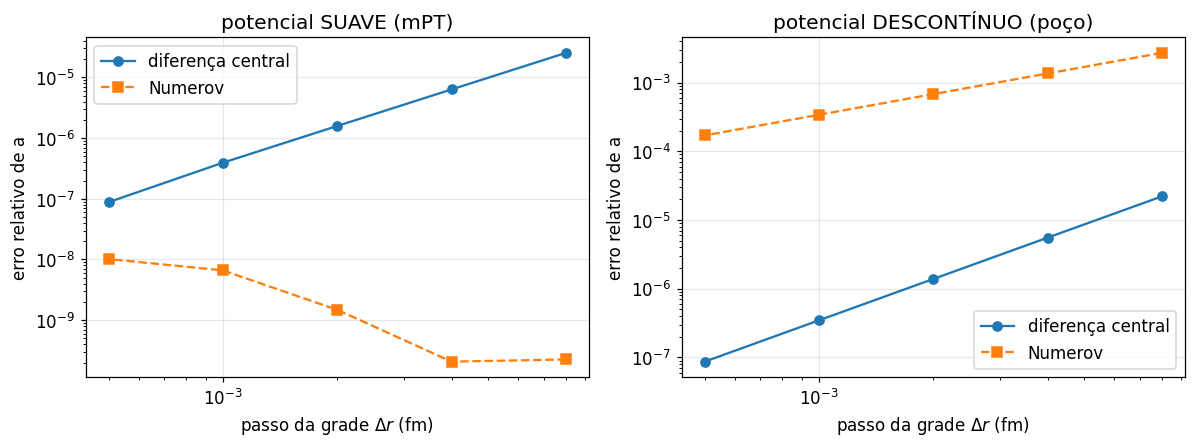

Esquerda: Numerov ganha por ~6 ordens de grandeza (como manda a teoria).
Direita: no poço com borda abrupta, Numerov PERDE para o método simples!
Lição de método: a ordem alta do Numerov PRESSUPÕE potencial suave (C4).


In [7]:
drs = np.array([8e-3, 4e-3, 2e-3, 1e-3, 5e-4])
a_mpt_exato = analitico.a_mpt(0.9071, 0.7991)          # fórmula exata (mPT)
a_poco_exato = analitico.a_poco(1.1096, 1/0.3918)      # fórmula exata (poço)

def erros(Pot, args, exato):
    out = {}
    for met in ('central', 'numerov'):
        out[met] = [abs(espalhamento.calcular(Pot(*args), dr=d, metodo=met).a
                        / exato - 1) for d in drs]
    return out

e_mpt = erros(PoschlTeller, (0.9071, 0.7991), a_mpt_exato)
e_poco = erros(PocoEsferico, (1.1096, 0.3918), a_poco_exato)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, e, titulo in ((ax1, e_mpt, 'potencial SUAVE (mPT)'),
                      (ax2, e_poco, 'potencial DESCONTÍNUO (poço)')):
    ax.loglog(drs, e['central'], 'o-', label='diferença central')
    ax.loglog(drs, e['numerov'], 's--', label='Numerov')
    ax.set_xlabel('passo da grade $\\Delta r$ (fm)')
    ax.set_ylabel('erro relativo de a')
    ax.set_title(titulo); ax.legend()
plt.tight_layout(); plt.show()

print('Esquerda: Numerov ganha por ~6 ordens de grandeza (como manda a teoria).')
print('Direita: no poço com borda abrupta, Numerov PERDE para o método simples!')
print('Lição de método: a ordem alta do Numerov PRESSUPÕE potencial suave (C4).')

📊 **Como ler (gráfico log-log — importante!):**

- **Eixo x:** o passo $\Delta r$ da grade. Para a ESQUERDA = grade mais fina
  = mais preciso (e mais lento). Cada marquinha é 10× menor.
- **Eixo y:** o erro relativo comparado com a fórmula exata. $10^{-10}$
  significa 10 casas decimais corretas.
- **Reta em escala log-log = lei de potência**: inclinação 2 = erro
  $\propto (\Delta r)^2$; inclinação 4 = erro $\propto (\Delta r)^4$.
- **Painel esquerdo:** Numerov (quadrados) despenca muito mais rápido —
  potencial suave, tudo como nos livros.
- **Painel direito — a surpresa:** a borda abrupta do poço quebra a
  hipótese de suavidade do Numerov e ele fica PIOR que o método simples.

🔧 **MEXA AQUI:** troque o poço por `Gaussiano(1.2121, 0.5672)` (use
`analitico` não tem fórmula exata pro gaussiano — use como "exato" o valor
com `dr=1e-4`). Suave de novo → Numerov volta a ganhar.

---
## Fechamento

Você acabou de percorrer, com as mãos, o esqueleto inteiro do artigo:

1. resolver $u'' = 2\bar V u$ marchando da origem (§1, §6),
2. ler $a$ na reta externa (§2) e validar contra fórmula exata (§3),
3. medir $r_0$ como área entre mundo ideal e mundo real (§4),
4. transformar $(a, r_0)$ em energia de estado ligado (§5).

**Próxima parada no seu mestrado:** no regime $|a| \to \infty$ (a parede
do §3), três partículas fazem algo que duas não fazem — os trímeros de
Efimov. Tudo daqui (unitariedade, alcance efetivo, potenciais tunados)
é o vocabulário desse próximo capítulo.